# Preambolo

In [ ]:
import numpy as np
import matplotlib as mtp
import scipy as sp
import matplotlib.pyplot as plt
import pandas as pd
import math
from scipy.stats import norm
from scipy.stats import chi2
from matplotlib.ticker import FormatStrFormatter
from scipy import stats
from scipy.constants import g
from scipy.constants import R
from matplotlib.ticker import ScalarFormatter
from matplotlib.ticker import StrMethodFormatter
!pip install uncertainties
from uncertainties import ufloat
from uncertainties import unumpy
from uncertainties.umath import sqrt


In [ ]:
!git clone https://github.com/matteodeclich/Esperienze-in-laboratorio.git
%cd Esperienze-in-laboratorio

Cloning into 'Esperienze-in-laboratorio'...
remote: Enumerating objects: 1107, done.
remote: Counting objects: 100% (175/175), done.
remote: Compressing objects: 100% (98/98), done.
remote: Total 1107 (delta 114), reused 135 (delta 77), pack-reused 932 (from 2)
Receiving objects: 100% (1107/1107), 18.44 MiB | 24.21 MiB/s, done.
Resolving deltas: 100% (580/580), done.
/content/Esperienze-in-laboratorio/Esperienze-in-laboratorio


In [ ]:
from Libreria_python import analisi_dati as ad

#Pull

In [ ]:
!git pull

Already up to date.


#Tubo aperto

In [ ]:
df=pd.read_excel('Tubo risonanza.xlsx', sheet_name=0)
df=df.fillna('')
df

,n,Frequenza (hz),Incertezza (hz),D diametro del tubo aperto,Temperatura stanza (k)
0,1.0,190.1,4.0,0.035,296.15
1,2.0,381.0,4.0,Incertezza (m),Incertezza temperatura (k)
2,3.0,561.0,4.0,0.005,0.5
3,4.0,760.2,4.0,Lunghezza tubo (m),Massa molare aria (kg/mol)
4,5.0,935.6,4.0,0.9,0.028965
5,,,,Incertezza (m),Incertezza (kg/mol)
6,,,,0.01,0.0005
7,,,,,γ
8,,,,,1.4
9,,,,,R gas ideale


Il risultato del fit y = k·x è:
  k = 188.25273±0.53936


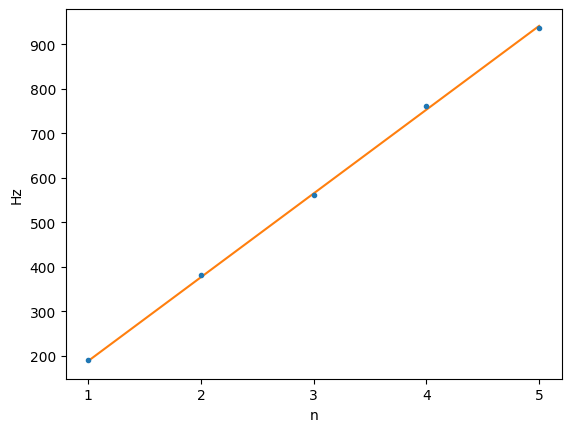

In [ ]:
n=df.iloc[0:5, 0]
n=pd.to_numeric(n, errors='coerce').dropna().values
f=df.iloc[0:5, 1]
f=pd.to_numeric(f, errors='coerce').dropna().values
sf = df.iloc[0:5, 2]
sf = pd.to_numeric(sf, errors='coerce').dropna().values
k = ad.minquadw_kx(n, f, sf)
def retta(x, k):
    return k * x
t= np.linspace(min(n), max(n))
plt.errorbar(n, f, yerr=sf, fmt='o', ls='none', label='Dati', ms=3)
plt.xticks(n)
plt.plot(t, retta(t, k.nominal_value))
plt.xlabel(r'n')
plt.ylabel(r'Hz')
plt.show()




In [ ]:
e=k*n
_,_,_,_=ad.chi_quadro(f, e, sf, 1)

Il risultato del test del χ² è:
  χ²               = 7.5935682
  Gradi di libertà = 4
  χ² ridotto       = 1.898392
  Il p-value associato è: 0.10765341


In [ ]:
L=ufloat(df.iloc[4, 3], df.iloc[6, 3])
D=ufloat(df.iloc[0, 3], df.iloc[2, 3])
v=2*(L+(0.8*D))*k
print(f"Velocità del suono sperimentale= {v:.8P}")

Velocità del suono sperimentale= 349.39706±4.17682


In [ ]:
R=df.iloc[10, 4]
γ=df.iloc[8, 4]
M=ufloat(df.iloc[4, 4], df.iloc[6, 4])
T=ufloat(df.iloc[0, 4], df.iloc[2, 4])
v_suono=sqrt((γ*R*T)/M)
print(f"Velocità del suono teorica: {v_suono:.8P}")

Velocità del suono teorica: 344.98679±2.99186


In [ ]:
t=ad.t_test(v, v_suono)

Test di compatibilità tra misura 1 e misura 2: |t| = 0.85839666


#Ventri e nodi

In [ ]:
df2=pd.read_excel('Tubo risonanza.xlsx', sheet_name=1)
df2=df2.fillna('')
df2

,n=4,n,Distanza (m),Incertezza (m),λ_n teorica,λ_n/2 osservata,V suono (m/s)
0,Ventri,1.5,0.345,0.005,0.453811,0.228,344.98679
1,,2.5,0.560,0.005,,0.225,Frequenza (hz)
2,,3.5,0.788,0.005,,0.220,760.2
3,Nodi,1.0,0.230,0.005,,0.215,
4,,2.0,0.450,0.005,Media,0.222,
5,,3.0,0.675,0.005,λ_n sperimentale,0.444,


In [ ]:

d_val = pd.to_numeric(df2.iloc[0:6, 2], errors='coerce').dropna().values
d_err = pd.to_numeric(df2.iloc[0:6, 3], errors='coerce').dropna().values
d_sperimentali = unumpy.uarray(d_val, d_err)
n_1 = pd.to_numeric(df2.iloc[0:6, 1], errors='coerce').dropna().values
f_fissa = df2.iloc[2, 6]

d_teoriche = n_1 * v_suono / (2 * f_fissa)

for i in range(len(d_teoriche)):
    print(f"Distanza teorica {i+1}: {d_teoriche[i]:.4P}")

for i in range(len(d_sperimentali)):
    print(f"Distanze sperimentali: {d_sperimentali[i]:.8P}")

Distanza teorica 1: 0.3404±0.0030
Distanza teorica 2: 0.5673±0.0049
Distanza teorica 3: 0.7942±0.0069
Distanza teorica 4: 0.2269±0.0020
Distanza teorica 5: 0.4538±0.0039
Distanza teorica 6: 0.6807±0.0059
Distanze sperimentali: 0.34500000±0.00500000
Distanze sperimentali: 0.56000000±0.00500000
Distanze sperimentali: 0.78800000±0.00500000
Distanze sperimentali: 0.23000000±0.00500000
Distanze sperimentali: 0.45000000±0.00500000
Distanze sperimentali: 0.67500000±0.00500000


In [ ]:
for i in range(len(d_teoriche)):
  ad.t_test(d_teoriche[i], d_sperimentali[i] )


Test di compatibilità tra misura 1 e misura 2: |t| = 0.79949644
Test di compatibilità tra misura 1 e misura 2: |t| = 1.0354709
Test di compatibilità tra misura 1 e misura 2: |t| = 0.72477435
Test di compatibilità tra misura 1 e misura 2: |t| = 0.57594496
Test di compatibilità tra misura 1 e misura 2: |t| = 0.59885224
Test di compatibilità tra misura 1 e misura 2: |t| = 0.73883294


#Tubo chiuso a un'estremità

In [ ]:
df1=pd.read_excel('Tubo risonanza.xlsx', sheet_name=2)
df1=df1.fillna('')
df1

,Unnamed: 0,80 cm,Unnamed: 2,65 cm,Unnamed: 4,Unnamed: 5,55 cm,Unnamed: 7
0,n,Frequenza (hz),Incertezza (hz),Frequenza (hz),Incertezza (hz),n,Frequenza (hz),Incertezza (hz)
1,3,319.2,5,377,5,5,760,5
2,5,534.3,5,632,5,7,1068,5
3,7,741.2,6,884,6,11,1688,6
4,9,954.1,6,1146,6,13,1990,6
5,11,1155.1,6,1404.5,6,15,2290,6


Il risultato del fit y = a + b·x è:
  a = 8.2274391±6.2104599
  b = 104.64856±0.86952
  Covarianza cov(a, b) = -4.9530243
Il risultato del fit y = a + b·x è:
  a = -4.9593544±6.7760912
  b = 153.33122±0.65906
  Covarianza cov(a, b) = -4.1574738
Il risultato del fit y = a + b·x è:
  a = -9.8076796±6.2104599
  b = 128.37822±0.86952
  Covarianza cov(a, b) = -4.9530243


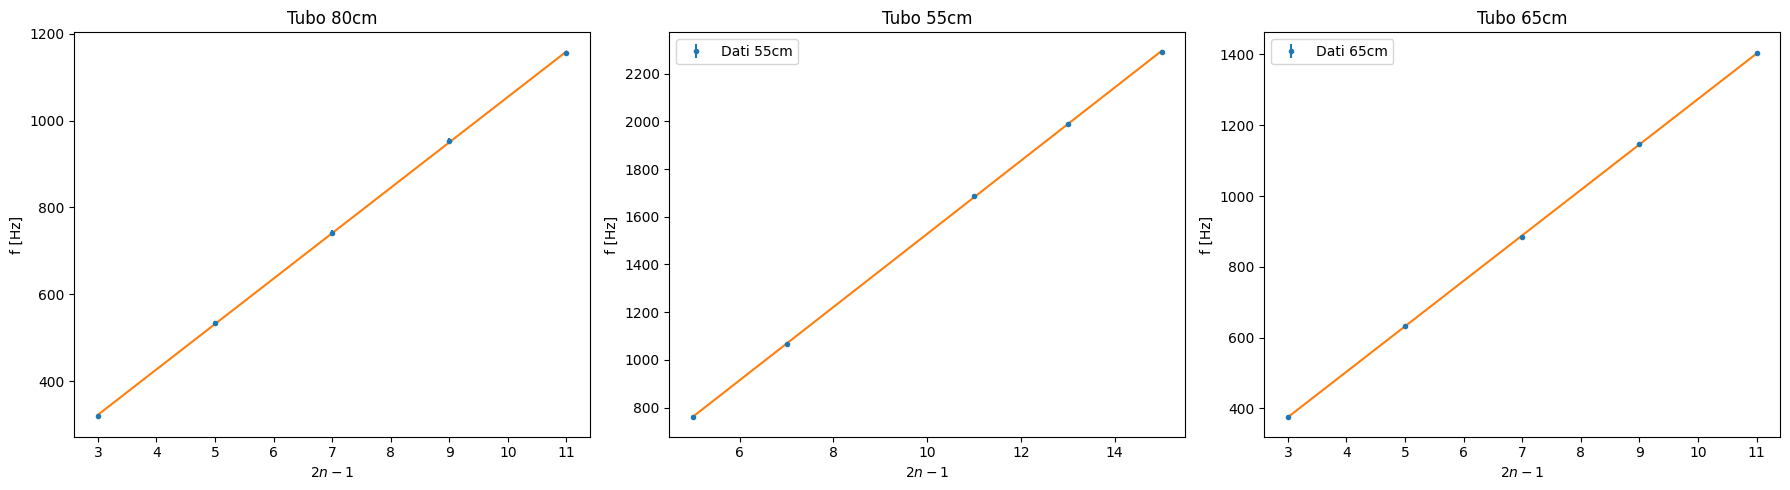

In [ ]:
n1 = pd.to_numeric(df1.iloc[1:6, 0], errors='coerce').dropna().values
f1 = pd.to_numeric(df1.iloc[1:6, 1], errors='coerce').dropna().values
sf1 = pd.to_numeric(df1.iloc[1:6, 2], errors='coerce').dropna().values

n2 = pd.to_numeric(df1.iloc[1:6, 5], errors='coerce').dropna().values
f2 = pd.to_numeric(df1.iloc[1:6, 6], errors='coerce').dropna().values
sf2 = pd.to_numeric(df1.iloc[1:6, 7], errors='coerce').dropna().values

n3 = n1
f3 = pd.to_numeric(df1.iloc[1:6, 3], errors='coerce').dropna().values
sf3 = pd.to_numeric(df1.iloc[1:6, 4], errors='coerce').dropna().values

a1, b1, _ = ad.minquadw_abx(n1, f1, sf1)
a2, b2, _ = ad.minquadw_abx(n2, f2, sf2)
a3, b3, _ = ad.minquadw_abx(n3, f3, sf3)

def retta(x, a, b):
    return a + b * x
t1 = np.linspace(min(n1), max(n1), 100)
t2 = np.linspace(min(n2), max(n2), 100)
t3 = np.linspace(min(n3), max(n3), 100)

import matplotlib.pyplot as plt

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# --- PLOT 1: 80cm ---
ax1.errorbar(n1, f1, yerr=sf1, fmt='o', ls='none', label='Dati 80cm', ms=3)
ax1.plot(t1, retta(t1, a1.nominal_value, b1.nominal_value))
ax1.set_title('Tubo 80cm')
ax1.set_xlabel(r'$2n-1$')
ax1.set_ylabel(r'f [Hz]')

# --- PLOT 2: 55cm ---
ax2.errorbar(n2, f2, yerr=sf2, fmt='o', ls='none', label='Dati 55cm', ms=3)
ax2.plot(t2, retta(t2, a2.nominal_value, b2.nominal_value))
ax2.set_title('Tubo 55cm')
ax2.set_xlabel(r'$2n-1$')
ax2.set_ylabel(r'f [Hz]')
ax2.legend()

# --- PLOT 3: 65cm ---
ax3.errorbar(n3, f3, yerr=sf3, fmt='o', ls='none', label='Dati 65cm', ms=3)
ax3.plot(t3, retta(t3, a3.nominal_value, b3.nominal_value))
ax3.set_title('Tubo 65cm')
ax3.set_xlabel(r'$2n-1$')
ax3.set_ylabel(r'f [Hz]')
ax3.legend()

plt.tight_layout()
plt.show()


Il risultato del fit y = k·x è:
  k = 105.70511±0.34643
Il risultato del fit y = k·x è:
  k = 152.88217±0.24066
Il risultato del fit y = k·x è:
  k = 127.11875±0.34643


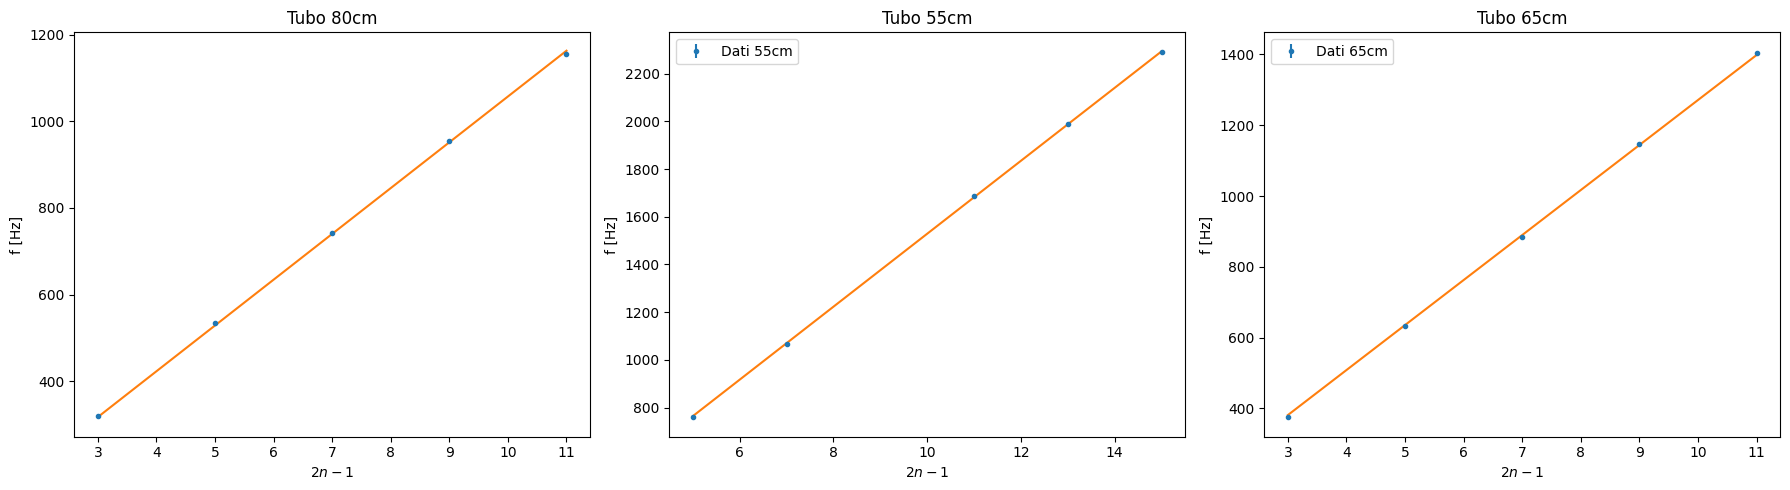

In [ ]:
# --- FIT PASSANTE PER L'ORIGINE ---

# Fit 80 cm
k1= ad.minquadw_kx(n1, f1, sf1)

# Fit 55 cm
k2 = ad.minquadw_kx(n2, f2, sf2)

# Fit 65 cm
k3= ad.minquadw_kx(n3, f3, sf3)

def retta0(x, k):
    return k * x

t1 = np.linspace(min(n1), max(n1), 100)
t2 = np.linspace(min(n2), max(n2), 100)
t3 = np.linspace(min(n3), max(n3), 100)

import matplotlib.pyplot as plt

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# --- PLOT 1: 80cm ---
ax1.errorbar(n1, f1, yerr=sf1, fmt='o', ls='none', label='Dati 80cm', ms=3)
ax1.plot(t1, retta0(t1, k1.nominal_value))
ax1.set_title('Tubo 80cm')
ax1.set_xlabel(r'$2n-1$')
ax1.set_ylabel(r'f [Hz]')

# --- PLOT 2: 55cm ---
ax2.errorbar(n2, f2, yerr=sf2, fmt='o', ls='none', label='Dati 55cm', ms=3)
ax2.plot(t2, retta0(t2, k2.nominal_value))
ax2.set_title('Tubo 55cm')
ax2.set_xlabel(r'$2n-1$')
ax2.set_ylabel(r'f [Hz]')
ax2.legend()

# --- PLOT 3: 65cm ---
ax3.errorbar(n3, f3, yerr=sf3, fmt='o', ls='none', label='Dati 65cm', ms=3)
ax3.plot(t3, retta0(t3, k3.nominal_value))
ax3.set_title('Tubo 65cm')
ax3.set_xlabel(r'$2n-1$')
ax3.set_ylabel(r'f [Hz]')
ax3.legend()

plt.tight_layout()
plt.show()


In [ ]:
e1=b1*n1+a1
e2=b2*n2+a2
e3=b3*n3+a3
_, _, _, _=ad.chi_quadro(f1, e1, sf1, 2)
_, _, _, _=ad.chi_quadro(f2, e2, sf2, 2)
_, _, _, _=ad.chi_quadro(f3, e3, sf3, 2)


Il risultato del test del χ² è:
  χ²               = 1.6359303
  Gradi di libertà = 3
  χ² ridotto       = 0.5453101
  Il p-value associato è: 0.65127058
Il risultato del test del χ² è:
  χ²               = 2.0012797
  Gradi di libertà = 3
  χ² ridotto       = 0.66709324
  Il p-value associato è: 0.57214114
Il risultato del test del χ² è:
  χ²               = 0.89551442
  Gradi di libertà = 3
  χ² ridotto       = 0.29850481
  Il p-value associato è: 0.82651015


In [ ]:
e1=k1*n1
e2=k2*n2
e3=k3*n3
_, _, _, _=ad.chi_quadro(f1, e1, sf1, 1)
_, _, _, _=ad.chi_quadro(f2, e2, sf2, 1)
_, _, _, _=ad.chi_quadro(f3, e3, sf3, 1)


Il risultato del test del χ² è:
  χ²               = 3.3909493
  Gradi di libertà = 4
  χ² ridotto       = 0.84773733
  Il p-value associato è: 0.49465222
Il risultato del test del χ² è:
  χ²               = 2.5369429
  Gradi di libertà = 4
  χ² ridotto       = 0.63423572
  Il p-value associato è: 0.63803304
Il risultato del test del χ² è:
  χ²               = 3.3894487
  Gradi di libertà = 4
  χ² ridotto       = 0.84736219
  Il p-value associato è: 0.4948857


In [ ]:
l1=0.80
l3=0.65
l2=0.55
v1=4*b1*(l1+0.4*D)
v2=4*b2*(l2+0.4*D)
v3=4*b3*(l3+0.4*D)
v1_k=4*k1*(l1+0.4*D)
v2_k=4*k2*(l2+0.4*D)
v3_k=4*k3*(l3+0.4*D)
print(f"{v1:.8P}\n", f"{v2:.8P}\n", f"{v3:.8P}")
print(f"{v1_k:.8P}\n", f"{v2_k:.8P}\n", f"{v3_k:.8P}")
t1=ad.t_test(v1, v_suono)
t2=ad.t_test(v2, v_suono)
t3=ad.t_test(v3, v_suono)
t1_k=ad.t_test(v1_k, v_suono)
t2_k=ad.t_test(v2_k, v_suono)
t3_k=ad.t_test(v3_k, v_suono)
t11=ad.t_test(v1_k, v)
t22=ad.t_test(v2_k, v)
t33=ad.t_test(v3_k, v)
t111=ad.t_test(v1, v)
t222=ad.t_test(v2, v)
t333=ad.t_test(v3, v)

340.73572±2.95235
 345.91523±1.92753
 340.97256±2.52752
344.17583±1.40977
 344.90217±1.33815
 337.62740±1.37143
Test di compatibilità tra misura 1 e misura 2: |t| = 1.0113678
Test di compatibilità tra misura 1 e misura 2: |t| = 0.26087095
Test di compatibilità tra misura 1 e misura 2: |t| = 1.024933
Test di compatibilità tra misura 1 e misura 2: |t| = 0.24519733
Test di compatibilità tra misura 1 e misura 2: |t| = 0.025817705
Test di compatibilità tra misura 1 e misura 2: |t| = 2.236078
Test di compatibilità tra misura 1 e misura 2: |t| = 1.2705948
Test di compatibilità tra misura 1 e misura 2: |t| = 1.1397718
Test di compatibilità tra misura 1 e misura 2: |t| = 2.9184764
Test di compatibilità tra misura 1 e misura 2: |t| = 1.781378
Test di compatibilità tra misura 1 e misura 2: |t| = 0.8331149
Test di compatibilità tra misura 1 e misura 2: |t| = 1.8498309


C'è uno shift nel numero di armoniche di n=2 per 80 e 65 centimentri, n=3 per 55 cm. Le frequenze fondamentali sono rispettivamente circa 105 Hz per 0.8 m, 150 hz per 0.55 m e circa 130 Hz per 0.65 m.
Bisogna inoltre confrontare la velocit


# TUBO CHIUSO 2

In [ ]:
df9=pd.read_excel('Tubo risonanza.xlsx', sheet_name=6)
df9.fillna('')


,Unnamed: 0,80 cm,Unnamed: 2,65 cm,Unnamed: 4,55 cm,Unnamed: 6,Temperatura stanza (k),Distanza dal tubo
0,n,Frequenza (hz),Incertezza (hz),Frequenza (hz),Incertezza (hz),Frequenza (hz),Incertezza (hz),294.65,"1,5 cm"
1,1,105,1,129.3,2,151,3,Incertezza temperatura (k),
2,3,315.6,1,386.6,2,456.5,3,0.5,
3,5,525.7,1,645.7,2,760,3,,
4,7,737.4,1,903.5,2,1063,3,,
5,9,949.3,1,1162.7,2,1380,3,,
6,11,1155.4,2,1430,3,1680,4,,


Il risultato del fit y = a + b·x è:
  a = -0.53411765±0.87503501
  b = 105.39294±0.14349
  Covarianza cov(a, b) = -0.10882353
Il risultato del fit y = a + b·x è:
  a = -1.8967910±1.7142946
  b = 129.60276±0.27043
  Covarianza cov(a, b) = -0.40149254
Il risultato del fit y = a + b·x è:
  a = -3.7478764±2.5453796
  b = 153.14942±0.39323
  Covarianza cov(a, b) = -0.86698842


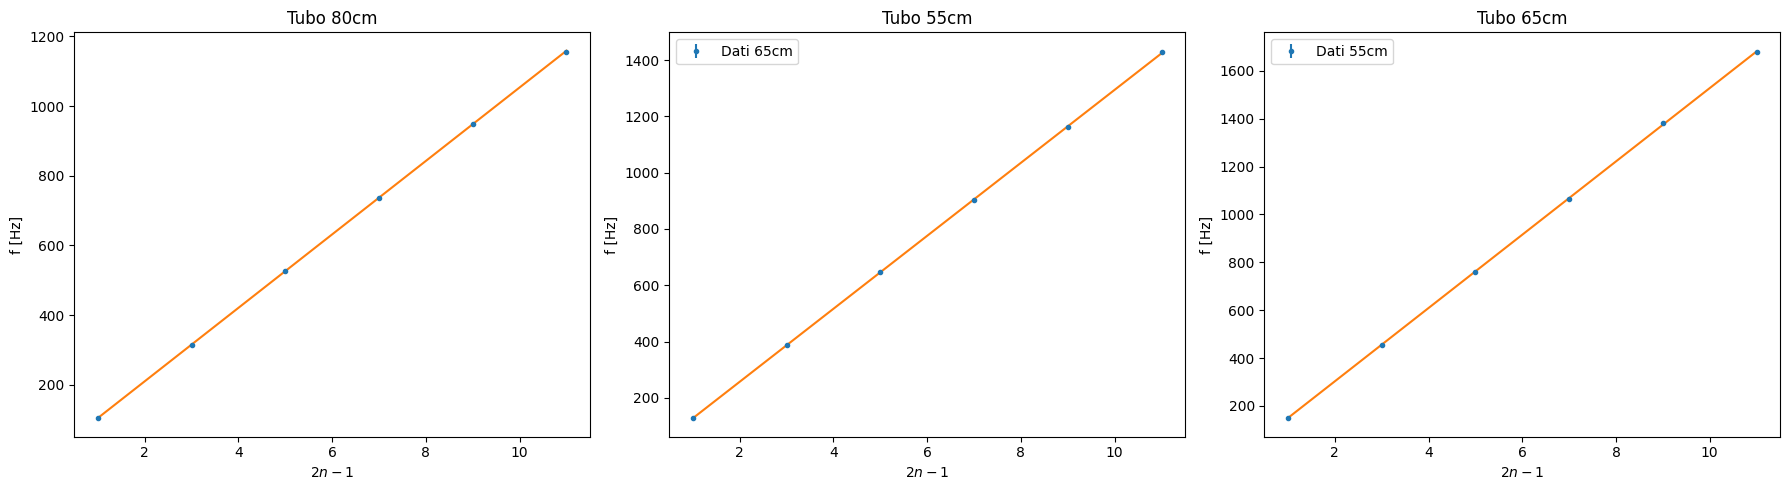

In [ ]:
n = pd.to_numeric(df9.iloc[1:7, 0], errors='coerce').dropna().values

f1 = pd.to_numeric(df9.iloc[1:7, 1], errors='coerce').dropna().values
sf1 = pd.to_numeric(df9.iloc[1:7, 2], errors='coerce').dropna().values

f2 = pd.to_numeric(df9.iloc[1:7, 3], errors='coerce').dropna().values
sf2 = pd.to_numeric(df9.iloc[1:7, 4], errors='coerce').dropna().values

f3 = pd.to_numeric(df9.iloc[1:7, 5], errors='coerce').dropna().values
sf3 = pd.to_numeric(df9.iloc[1:7, 6], errors='coerce').dropna().values

a1, b1, _ = ad.minquadw_abx(n, f1, sf1)
a2, b2, _ = ad.minquadw_abx(n, f2, sf2)
a3, b3, _ = ad.minquadw_abx(n, f3, sf3)

def retta(x, a, b):
    return a + b * x
t1 = np.linspace(min(n), max(n), 100)


import matplotlib.pyplot as plt

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# --- PLOT 1: 80cm ---
ax1.errorbar(n, f1, yerr=sf1, fmt='o', ls='none', label='Dati 80cm', ms=3)
ax1.plot(t1, retta(t1, a1.nominal_value, b1.nominal_value))
ax1.set_title('Tubo 80cm')
ax1.set_xlabel(r'$2n-1$')
ax1.set_ylabel(r'f [Hz]')

# --- PLOT 2: 65cm ---
ax2.errorbar(n, f2, yerr=sf2, fmt='o', ls='none', label='Dati 65cm', ms=3)
ax2.plot(t1, retta(t1, a2.nominal_value, b2.nominal_value))
ax2.set_title('Tubo 55cm')
ax2.set_xlabel(r'$2n-1$')
ax2.set_ylabel(r'f [Hz]')
ax2.legend()

# --- PLOT 3: 55cm ---
ax3.errorbar(n, f3, yerr=sf3, fmt='o', ls='none', label='Dati 55cm', ms=3)
ax3.plot(t1, retta(t1, a3.nominal_value, b3.nominal_value))
ax3.set_title('Tubo 65cm')
ax3.set_xlabel(r'$2n-1$')
ax3.set_ylabel(r'f [Hz]')
ax3.legend()

plt.tight_layout()
plt.show()


In [ ]:
e1=b1*n+a1
e2=b2*n+a2
e3=b3*n+a3
_, _, _, _=ad.chi_quadro(f1, e1, sf1, 2)
_, _, _, _=ad.chi_quadro(f2, e2, sf2, 2)
_, _, _, _=ad.chi_quadro(f3, e3, sf3, 2)


Il risultato del test del χ² è:
  χ²               = 5.1432941
  Gradi di libertà = 4
  χ² ridotto       = 1.2858235
  Il p-value associato è: 0.27290809
Il risultato del test del χ² è:
  χ²               = 6.7319366
  Gradi di libertà = 4
  χ² ridotto       = 1.6829841
  Il p-value associato è: 0.15075063
Il risultato del test del χ² è:
  χ²               = 7.2117332
  Gradi di libertà = 4
  χ² ridotto       = 1.8029333
  Il p-value associato è: 0.12511328


Il risultato del fit y = k·x è:
  k = 105.31703±0.07157
Il risultato del fit y = k·x è:
  k = 129.34363±0.13522
Il risultato del fit y = k·x è:
  k = 152.64789±0.19651


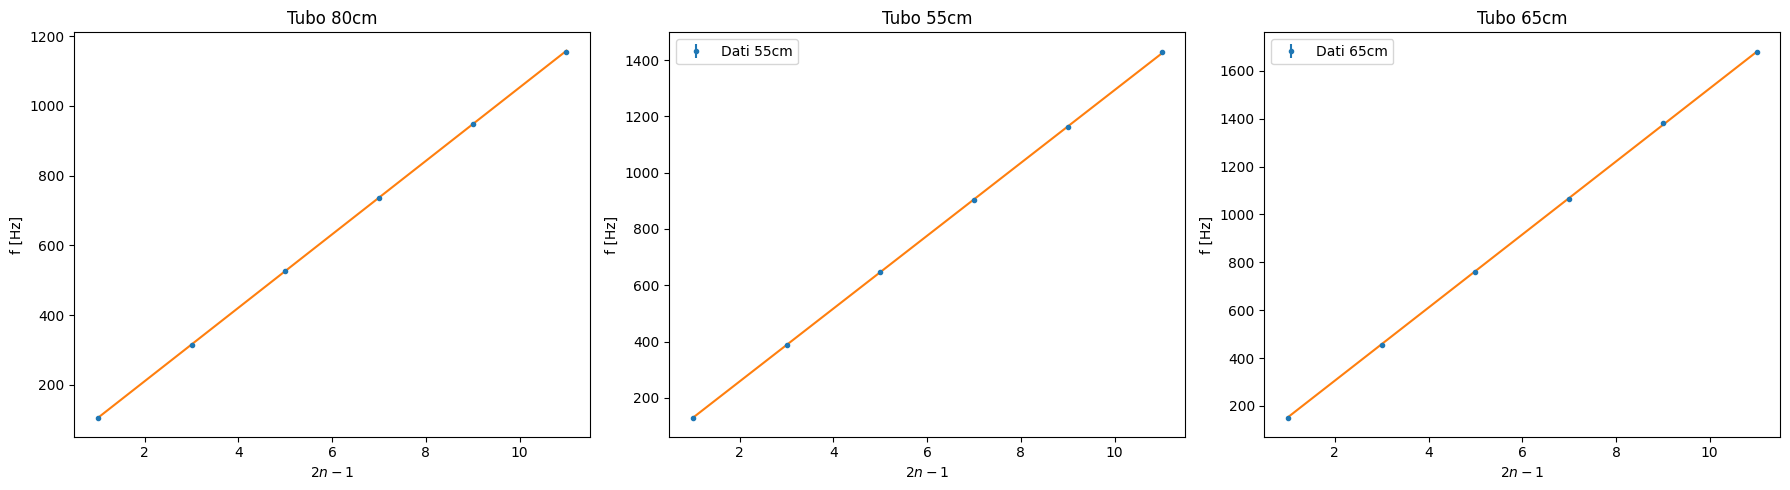

In [ ]:
 #--- FIT PASSANTE PER L'ORIGINE ---

# Fit 80 cm
k1= ad.minquadw_kx(n, f1, sf1)

# Fit 55 cm
k2 = ad.minquadw_kx(n, f2, sf2)

# Fit 65 cm
k3= ad.minquadw_kx(n, f3, sf3)

def retta0(x, k):
    return k * x

t = np.linspace(min(n), max(n), 100)


import matplotlib.pyplot as plt

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# --- PLOT 1: 80cm ---
ax1.errorbar(n, f1, yerr=sf1, fmt='o', ls='none', label='Dati 80cm', ms=3)
ax1.plot(t, retta0(t, k1.nominal_value))
ax1.set_title('Tubo 80cm')
ax1.set_xlabel(r'$2n-1$')
ax1.set_ylabel(r'f [Hz]')

# --- PLOT 2: 55cm ---
ax2.errorbar(n, f2, yerr=sf2, fmt='o', ls='none', label='Dati 55cm', ms=3)
ax2.plot(t, retta0(t, k2.nominal_value))
ax2.set_title('Tubo 55cm')
ax2.set_xlabel(r'$2n-1$')
ax2.set_ylabel(r'f [Hz]')
ax2.legend()

# --- PLOT 3: 65cm ---
ax3.errorbar(n, f3, yerr=sf3, fmt='o', ls='none', label='Dati 65cm', ms=3)
ax3.plot(t, retta0(t, k3.nominal_value))
ax3.set_title('Tubo 65cm')
ax3.set_xlabel(r'$2n-1$')
ax3.set_ylabel(r'f [Hz]')
ax3.legend()

plt.tight_layout()
plt.show()

In [ ]:
e1=k1*n
e2=k2*n
e3=k3*n
_, _, _, _=ad.chi_quadro(f1, e1, sf1, 1)
_, _, _, _=ad.chi_quadro(f2, e2, sf2, 1)
_, _, _, _=ad.chi_quadro(f3, e3, sf3, 1)


Il risultato del test del χ² è:
  χ²               = 5.5158771
  Gradi di libertà = 5
  χ² ridotto       = 1.1031754
  Il p-value associato è: 0.35620804
Il risultato del test del χ² è:
  χ²               = 7.9561808
  Gradi di libertà = 5
  χ² ridotto       = 1.5912362
  Il p-value associato è: 0.15866718
Il risultato del test del χ² è:
  χ²               = 9.3797637
  Gradi di libertà = 5
  χ² ridotto       = 1.8759527
  Il p-value associato è: 0.094842205


In [ ]:
l1=0.80
l2=0.65
l3=0.55
v1=4*b1*(l1+0.4*D)
v2=4*b2*(l2+0.4*D)
v3=4*b3*(l3+0.4*D)
v1_k=4*k1*(l1+0.4*D)
v2_k=4*k2*(l2+0.4*D)
v3_k=4*k3*(l3+0.4*D)
T1=ufloat(df9.iloc[0, 7], df9.iloc[2, 7])
v_suono_teorica=sqrt((γ*R*T1)/M)
print(f"{v1:.8P}\n", f"{v2:.8P}\n", f"{v3:.8P}")
print(f"{v1_k:.8P}\n", f"{v2_k:.8P}\n", f"{v3_k:.8P}")
t1=ad.t_test(v1, v_suono_teorica)
t2=ad.t_test(v2, v_suono_teorica)
t3=ad.t_test(v3, v_suono_teorica)
t1_k=ad.t_test(v1_k, v_suono_teorica)
t2_k=ad.t_test(v2_k, v_suono_teorica)
t3_k=ad.t_test(v3_k, v_suono_teorica)
t11=ad.t_test(v1_k, v)
t22=ad.t_test(v2_k, v)
t33=ad.t_test(v3_k, v)
t111=ad.t_test(v1, v)
t222=ad.t_test(v2, v)
t333=ad.t_test(v3, v)

343.15942±0.96393
 344.22493±1.26131
 345.50509±1.51265
342.91225±0.87417
 343.53667±1.09530
 344.37365±1.29916
Test di compatibilità tra misura 1 e misura 2: |t| = 0.30373554
Test di compatibilità tra misura 1 e misura 2: |t| = 0.034856515
Test di compatibilità tra misura 1 e misura 2: |t| = 0.41636265
Test di compatibilità tra misura 1 e misura 2: |t| = 0.38579597
Test di compatibilità tra misura 1 e misura 2: |t| = 0.18097411
Test di compatibilità tra misura 1 e misura 2: |t| = 0.080386562
Test di compatibilità tra misura 1 e misura 2: |t| = 1.6380676
Test di compatibilità tra misura 1 e misura 2: |t| = 1.487159
Test di compatibilità tra misura 1 e misura 2: |t| = 1.2777868
Test di compatibilità tra misura 1 e misura 2: |t| = 1.5674942
Test di compatibilità tra misura 1 e misura 2: |t| = 1.2965291
Test di compatibilità tra misura 1 e misura 2: |t| = 0.97166863


# Argon e kripton

In [ ]:
df3=pd.read_excel('Tubo risonanza.xlsx', sheet_name=3)
df3=df3.fillna('')
df3


,Argon,Unnamed: 1,Unnamed: 2,Unnamed: 3,Kripton,Unnamed: 5,Unnamed: 6,Unnamed: 7
0,n,Frequenza (hz),Incertezza (hz),L (m),n,Frequenza (hz),Incertezza (hz),L (m)
1,4,440.2,4,1.45,3,314.5,4,1.45
2,5,549.5,4,T (K),4,400,4,T (K)
3,6,659.5,4,296.65,5,500,4,296.65
4,7,769.5,4,Incertezza temperatura (k),6,600,4,Incertezza temperatura (k)
5,8,882,4,0.5,7,700,4,0.5
6,,,,Massa molare (kg/mol),,,,Massa molare (kg/mol)
7,,,,0.039948,,,,0.083798
8,,,,Incertezza (kg/mol),,,,Incertezza (kg/mol)
9,,,,0.0005,,,,0.0005


Il risultato del fit y = a + b·x è:
  a = -2.0200000±7.7974355
  b = 110.36000±1.26491
  Covarianza cov(a, b) = -9.6
Il risultato del fit y = a + b·x è:
  a = 17.400000±6.572671
  b = 97.100000±1.264911
  Covarianza cov(a, b) = -8


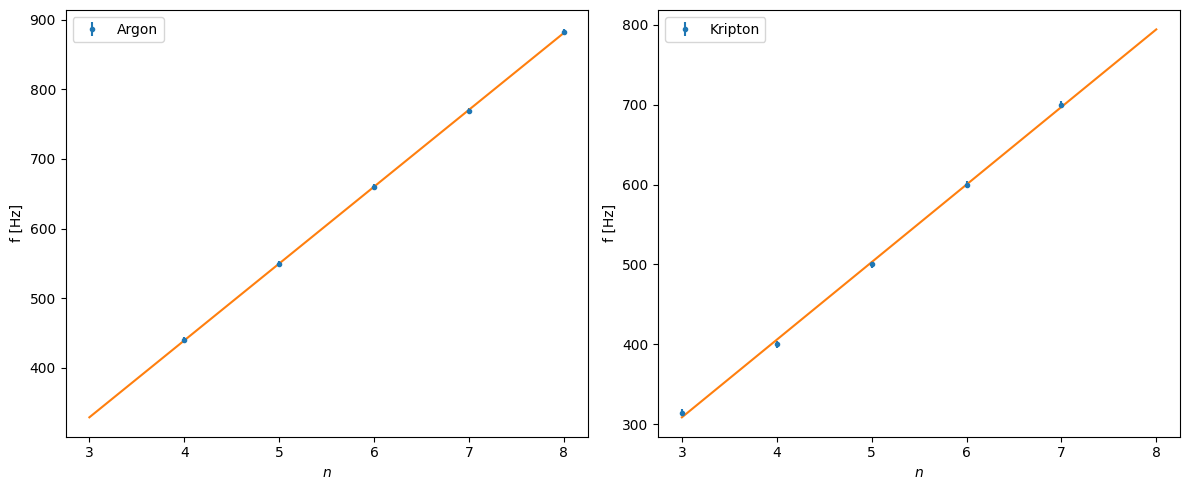

In [ ]:
n_2=pd.to_numeric(df3.iloc[1:6, 0], errors='coerce').dropna().values
n_3=pd.to_numeric(df3.iloc[1:6, 4], errors='coerce').dropna().values
fa=pd.to_numeric(df3.iloc[1:6, 1], errors='coerce').dropna().values
sfa=pd.to_numeric(df3.iloc[1:6, 2], errors='coerce').dropna().values
fk=pd.to_numeric(df3.iloc[1:6, 5], errors='coerce').dropna().values
sfk=pd.to_numeric(df3.iloc[1:6, 6], errors='coerce').dropna().values

def retta_lineare(x, a, b):
    return a + b * x
a4, b4, _ = ad.minquadw_abx(n_2, fa, sfa)
a5, b5, _ = ad.minquadw_abx(n_3, fk, sfk)

t=np.linspace(min(n_3), max(n_2))

# Creo una figura con 1 riga e 2 colonne
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- PLOT 1: Argon ---
ax1.errorbar(n_2, fa, yerr=sfa, fmt='o', ls='none', label='Argon', ms=3)
ax1.plot(t, retta_lineare(t, a4.nominal_value, b4.nominal_value))
ax1.set_xlabel(r'$n$')
ax1.set_ylabel(r'f [Hz]')
ax1.legend()

# --- PLOT 2: Kripton ---
ax2.errorbar(n_3, fk, yerr=sfk, fmt='o', ls='none', label='Kripton', ms=3)
ax2.plot(t, retta_lineare(t, a5.nominal_value, b5.nominal_value))
ax2.set_xlabel(r'$n$')
ax2.set_ylabel(r'f [Hz]')
ax2.legend()

# Sistema gli spazi ed evita sovrapposizioni
plt.tight_layout()
plt.show()

Il risultato del fit y = k·x è:
  k = 110.04105±0.29019
Il risultato del fit y = k·x è:
  k = 100.32222±0.34427


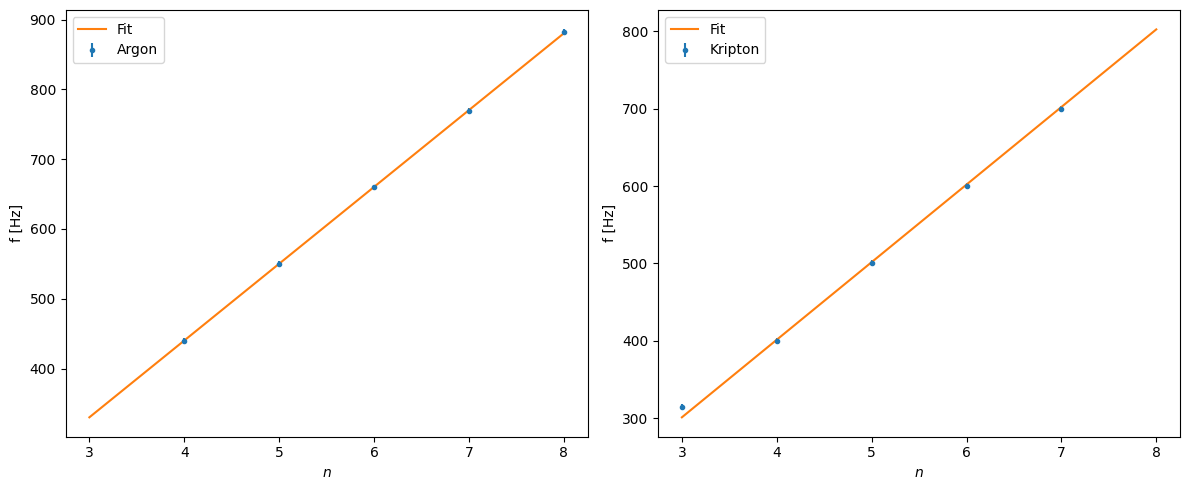

In [ ]:
# --- FIT PASSANTE PER L'ORIGINE ---

# Argon
k4 = ad.minquadw_kx(n_2, fa, sfa)

# Kripton
k5 = ad.minquadw_kx(n_3, fk, sfk)

def retta0(x, k):
    return k * x

t = np.linspace(min(min(n_2), min(n_3)), max(max(n_2), max(n_3)), 200)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- PLOT 1: Argon ---
ax1.errorbar(n_2, fa, yerr=sfa, fmt='o', ls='none', label='Argon', ms=3)
ax1.plot(t, retta0(t, k4.nominal_value), label='Fit')
ax1.set_xlabel(r'$n$')
ax1.set_ylabel(r'f [Hz]')
ax1.legend()

# --- PLOT 2: Kripton ---
ax2.errorbar(n_3, fk, yerr=sfk, fmt='o', ls='none', label='Kripton', ms=3)
ax2.plot(t, retta0(t, k5.nominal_value), label='Fit')
ax2.set_xlabel(r'$n$')
ax2.set_ylabel(r'f [Hz]')
ax2.legend()

plt.tight_layout()
plt.show()


Frequenza fondamentale Argon circa 110 Hz.
Frequenza fondamentale Kripton circa 100 Hz.
Bisogna rimisurare le armoniche partendo da n=1.


In [ ]:
e4=b4*n_2+a4
e5=b5*n_3+a5
_, _, _, _=ad.chi_quadro(fa, e4, sfa, 2)
_, _, _, _=ad.chi_quadro(fk, e5, sfk, 2)

Il risultato del test del χ² è:
  χ²               = 0.21225
  Gradi di libertà = 3
  χ² ridotto       = 0.07075
  Il p-value associato è: 0.97558792
Il risultato del test del χ² è:
  χ²               = 5.25625
  Gradi di libertà = 3
  χ² ridotto       = 1.7520833
  Il p-value associato è: 0.15396659


In [ ]:
e41=k4*n_2
e51=k5*n_3
_, _, _, _=ad.chi_quadro(fa, e41, sfa, 1)
_, _, _, _=ad.chi_quadro(fk, e51, sfk, 1)

Il risultato del test del χ² è:
  χ²               = 0.27936184
  Gradi di libertà = 4
  χ² ridotto       = 0.069840461
  Il p-value associato è: 0.99110719
Il risultato del test del χ² è:
  χ²               = 12.264583
  Gradi di libertà = 4
  χ² ridotto       = 3.0661458
  Il p-value associato è: 0.015488475


In [ ]:
L_tubo=df3.iloc[1, 7]
M_a=ufloat(df3.iloc[7, 3], df3.iloc[9, 3])
M_k=ufloat(df3.iloc[7, 7], df3.iloc[9, 3])
γ_m=df3.iloc[11, 3]
T_stanza=ufloat(df3.iloc[3, 7], df3.iloc[5, 7])
v_suono_argon=2*b4*(L_tubo+0.4*D)
v_suono_kripton=2*b5*(L_tubo+0.4*D)
v_suono1_teorica=sqrt((γ_m*R*T_stanza)/M_a)
v_suono2_teorica=sqrt((γ_m*R*T_stanza)/M_k)
v_suono_argon1=2*k4*(L_tubo+0.4*D)
v_suono_kripton1=2*k5*(L_tubo+0.4*D)
print(f"Velocità del suono Argon: {v_suono_argon:.8P}")
print(f"Velocità del suono Kripton: {v_suono_kripton:.8P}")
print(f"Velocità del suono Argon teorica: {v_suono1_teorica:.8P}")
print(f"Velocità del suono Kripton teorica: {v_suono2_teorica:.8P}")
print(f"Velocità del suono Argon sperimentale: {v_suono_argon1:.8P}")
print(f"Velocità del suono Kripton sperimentale: {v_suono_kripton1:.8P}")

Velocità del suono Argon: 323.13408±3.72987
Velocità del suono Kripton: 284.30880±3.72397
Velocità del suono Argon teorica: 320.78653±2.02565
Velocità del suono Kripton teorica: 221.48627±0.68663
Velocità del suono Argon sperimentale: 322.20020±0.95692
Velocità del suono Kripton sperimentale: 293.74347±1.08495


In [ ]:
t4=ad.t_test(v_suono_argon, v_suono1_teorica)
t5=ad.t_test(v_suono_kripton, v_suono2_teorica)

Test di compatibilità tra misura 1 e misura 2: |t| = 0.55308937
Test di compatibilità tra misura 1 e misura 2: |t| = 16.590127


#ARGON E KRIPTON 2

In [ ]:
df7=pd.read_excel('Tubo risonanza.xlsx', sheet_name=7)
df7=df7.fillna('')
df7

,Argon,Unnamed: 1,Unnamed: 2,Unnamed: 3,Kripton,Unnamed: 5,Unnamed: 6,Unnamed: 7
0,n,Frequenza (hz),Incertezza (hz),L (m),n,Frequenza (hz),Incertezza (hz),L (m)
1,1,112,5,1.46,1,94,5,1.454
2,2,225,5,T (K),2,188,5,T (K)
3,3,338,5,295.65,3,282,5,295.15
4,4,450,5,Incertezza temperatura (k),4,375,5,Incertezza temperatura (k)
5,5,562,5,0.5,5,469,5,0.5
6,6,676,5,Massa molare (kg/mol),6,560,5,Massa molare (kg/mol)
7,,,,0.039948,,,,0.083798
8,,,,Incertezza (kg/mol),,,,Incertezza (kg/mol)
9,,,,0.0005,,,,0.0005


In [ ]:
n=pd.to_numeric(df7.iloc[1:7, 0], errors='coerce').dropna().values
fa=pd.to_numeric(df7.iloc[1:7, 1], errors='coerce').dropna().values
sfa=pd.to_numeric(df7.iloc[1:7, 2], errors='coerce').dropna().values
fk=pd.to_numeric(df7.iloc[1:7, 5], errors='coerce').dropna().values
sfk=pd.to_numeric(df7.iloc[1:7, 6], errors='coerce').dropna().values

# --- FIT PASSANTE PER L'ORIGINE ---

# Argon
k4 = ad.minquadw_kx(n, fa, sfa)

# Kripton
k5 = ad.minquadw_kx(n_3, fk, sfk)

def retta0(x, k):
    return k * x

t = np.linspace(min(min(n_2), min(n_3)), max(max(n_2), max(n_3)), 200)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- PLOT 1: Argon ---
ax1.errorbar(n_2, fa, yerr=sfa, fmt='o', ls='none', label='Argon', ms=3)
ax1.plot(t, retta0(t, k4.nominal_value), label='Fit')
ax1.set_xlabel(r'$n$')
ax1.set_ylabel(r'f [Hz]')
ax1.legend()

# --- PLOT 2: Kripton ---
ax2.errorbar(n_3, fk, yerr=sfk, fmt='o', ls='none', label='Kripton', ms=3)
ax2.plot(t, retta0(t, k5.nominal_value), label='Fit')
ax2.set_xlabel(r'$n$')
ax2.set_ylabel(r'f [Hz]')
ax2.legend()

plt.tight_layout()
plt.show()




Il risultato del fit y = k·x è:
  k = 112.54945±0.52414


ValueError: operands could not be broadcast together with shapes (6,) (5,) 

In [ ]:
e4=b4*n_2+a4
e5=b5*n_3+a5
ad.chi_quadro(fa, e4, sfa, 2);
ad.chi_quadro(fk, e5, sfk, 2);

In [ ]:
e41=k4*n_2
e51=k5*n_3
ad.chi_quadro(fa, e41, sfa, 1);
ad.chi_quadro(fk, e51, sfk, 1);

In [ ]:
L_tubo_argon=df7.iloc[1, 3]
L_tubo_kripton=df7.iloc[1, 7]
M_a=ufloat(df7.iloc[7, 3], df7.iloc[9, 3])
M_k=ufloat(df7.iloc[7, 7], df7.iloc[9, 3])
γ_m=df7.iloc[11, 3]
T_stanza_argon=ufloat(df7.iloc[3, 3], df7.iloc[5, 3])
T_stanza_kripton=ufloat(df7.iloc[3, 7], df7.iloc[5, 7])
v_suono1_teorica=sqrt((γ_m*R*T_stanza_argon)/M_a)
v_suono2_teorica=sqrt((γ_m*R*T_stanza_kripton)/M_k)
v_suono_argon=2*k4*(L_tubo_argon)
v_suono_kripton=2*k5*(L_tubo_kripton)
print(f"Velocità del suono Argon teorica: {v_suono1_teorica:.8P}")
print(f"Velocità del suono Kripton teorica: {v_suono2_teorica:.8P}")
print(f"Velocità del suono Argon sperimentale: {v_suono_argon:.8P}")
print(f"Velocità del suono Kripton sperimentale: {v_suono_kripton:.8P}")

In [ ]:
t4=ad.t_test(v_suono_argon, v_suono1_teorica)
t5=ad.t_test(v_suono_kripton, v_suono2_teorica)

# Onde quadre (aria)




In [ ]:
df4=pd.read_excel('Tubo risonanza.xlsx', sheet_name=4)
df4=df4.fillna('')
df4

In [ ]:
x=pd.to_numeric(df4.iloc[0:6, 0], errors='coerce').dropna().values
t=pd.to_numeric(df4.iloc[0:6, 4], errors='coerce').dropna().values
sx=pd.to_numeric(df4.iloc[0:6, 1], errors='coerce').dropna().values
k5=ad.minquadw_kx(t, x, sx)
x_plot = np.linspace(min(t), max(t))

plt.errorbar(t, x, yerr=sx, fmt='o', ls='none', label='Dati', ms=3)

plt.plot(x_plot, x_plot * k5.nominal_value, label='Fit')
plt.xlabel(r'$\Delta$t [s]')
plt.ylabel(r'$\Delta$x [m]')
plt.legend()
plt.show()

In [ ]:
e6 = k5 * t
sx_array = np.full_like(x, sx)

_, _, _, _ = ad.chi_quadro(x, e6, sx_array, 1)

In [ ]:
t6=ad.t_test(k5, v_suono)

# ONDE QUADRE ARGON E KRIPTON

In [ ]:
df6=pd.read_excel('Tubo risonanza.xlsx', sheet_name=8)
df6=df6.fillna('')
df6

In [ ]:
x=df6.iloc[1, 0]
dta=ufloat(df6.iloc[1, 8], df6.iloc[1, 9])
dtk=ufloat(df6.iloc[3, 8], df6.iloc[3, 9])
v_suono_argon_quadra=x/dta
v_suono_kripton_quadra=x/dtk
print(f"Velocità del suono Argon : {v_suono_argon_quadra:.8P}")
print(f"Velocità del suono Kripton : {v_suono_kripton_quadra:.8P}")




In [ ]:
t1=ad.t_test(v_suono_argon_quadra, v_suono1_teorica);
t2=ad.t_test(v_suono_kripton_quadra, v_suono2_teorica);

# Ampiezza e fase

In [ ]:
df5=pd.read_excel('Tubo risonanza.xlsx', sheet_name=5)
df5.fillna('')
df5

In [ ]:
# Dati
f = pd.to_numeric(df5.iloc[0:6, 0], errors='coerce').dropna().values
A = pd.to_numeric(df5.iloc[0:6, 1], errors='coerce').dropna().values
t=pd.to_numeric(df5.iloc[0:6, 2], errors='coerce').dropna().values
plt.figure(figsize=(7,5))
plt.scatter(f, A, label="Dati sperimentali")
plt.plot(f, A, label="Fit", linestyle='dashed')


plt.xlabel("Frequenza (Hz)")
plt.ylabel("Ampiezza")
plt.title("Forma della risonanza: ampiezza in funzione della frequenza")
plt.legend()
plt.show()



In [ ]:
φ=2*np.pi*t*f
plt.scatter(f, φ, label="Dati sperimentali", s=16)
plt.plot(f, φ, label="Fit", linestyle='dashed')
plt.xlabel("Frequenza (Hz)")
plt.ylabel("Fase (rad)")
plt.legend()
plt.show()

#AMPIEZZA E FASE 2




In [ ]:
df8=pd.read_excel('Tubo risonanza.xlsx', sheet_name=9)
df8.fillna('')


In [ ]:
# Dati
f = pd.to_numeric(df8.iloc[2:13, 0], errors='coerce').dropna().values
A = pd.to_numeric(df8.iloc[2:13, 1], errors='coerce').dropna().values
t=pd.to_numeric(df8.iloc[2:13, 2], errors='coerce').dropna().values
print(t)
plt.figure(figsize=(7,5))
plt.scatter(f, A, label="Dati sperimentali")
plt.plot(f, A, label="Fit", linestyle='dashed')


plt.xlabel("Frequenza (Hz)")
plt.ylabel("Ampiezza")
plt.title("Forma della risonanza: ampiezza in funzione della frequenza")
plt.legend()
plt.show()


In [ ]:
φ=2*np.pi*t*f
plt.scatter(f, φ, label="Dati sperimentali", s=16)
plt.plot(f, φ, label="Fit", linestyle='dashed')
plt.xlabel("Frequenza (Hz)")
plt.ylabel("Fase (rad)")
plt.legend()
plt.show()